#Análise Exploratória de Dados — Projeto RH
# Disciplina: Visualização de Dados e Business Intelligence
# Dados: FreeSQL · Schema Human Resources (HR)

In [1]:
#IMPORTAR AS BIBLIOTECAS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import files

In [2]:
print("Faça o upload dos arquivos query_01.csv e query_02.csv:")
uploaded = files.upload()

Faça o upload dos arquivos query_01.csv e query_02.csv:


Saving query_01.csv to query_01.csv
Saving query_02.csv to query_02.csv


In [3]:
#CARREGAR OS DADOS

df_salarios = pd.read_csv('query_01.csv')
df_regioes  = pd.read_csv('query_02.csv')

# PADRONIZAR O NOME DA COLUNA DE SALÁRIO
df_salarios = df_salarios.rename(
    columns={'EMPLOYEE_SALARY': 'SALARY'}
)

In [4]:
#EXPLORAR OS DADOS COLETADOS

print("=" * 55)
print("QUERY 1 — Salários por Departamento e Cargo")
print("=" * 55)
print(df_salarios.head())
print(df_salarios.info())
print(df_salarios.shape)

print("\n" + "=" * 55)
print("QUERY 2 — Funcionários por Região")
print("=" * 55)
print(df_regioes.head())
print(df_regioes.info())
print(df_regioes.shape)

QUERY 1 — Salários por Departamento e Cargo
   EMPLOYEE_ID        FULL_NAME  SALARY DEPARTMENT_NAME  \
0          205  Shelley Higgins   12008      Accounting   
1          206    William Gietz    8300      Accounting   
2          200  Jennifer Whalen    4400  Administration   
3          100      Steven King   24000       Executive   
4          101       Neena Yang   17000       Executive   

                       JOB_TITLE  JOB_MIN_SALARY  JOB_MAX_SALARY  
0             Accounting Manager            8200           16000  
1              Public Accountant            4200            9000  
2       Administration Assistant            3000            6000  
3                      President           20080           40000  
4  Administration Vice President           15000           30000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   

In [5]:
#VERIFICAR DADOS AUSENTES

print("--- Valores ausentes (Query 1) ---")
print(df_salarios.isnull().sum())

print("\n--- Duplicatas (Query 1) ---")
print(df_salarios.duplicated().sum())

print("\n--- Valores ausentes (Query 2) ---")
print(df_regioes.isnull().sum())

df_salarios = df_salarios.dropna(subset=['SALARY'])
df_regioes  = df_regioes.dropna(subset=['SALARY'])

df_salarios['SALARY'] = pd.to_numeric(df_salarios['SALARY'])
df_regioes['SALARY']  = pd.to_numeric(df_regioes['SALARY'])

--- Valores ausentes (Query 1) ---
EMPLOYEE_ID        0
FULL_NAME          0
SALARY             0
DEPARTMENT_NAME    0
JOB_TITLE          0
JOB_MIN_SALARY     0
JOB_MAX_SALARY     0
dtype: int64

--- Duplicatas (Query 1) ---
0

--- Valores ausentes (Query 2) ---
EMPLOYEE_ID        0
FULL_NAME          0
SALARY             0
DEPARTMENT_NAME    0
CITY               0
STATE_PROVINCE     1
COUNTRY_NAME       0
REGION_NAME        0
dtype: int64


In [6]:
df_regioes[df_regioes['STATE_PROVINCE'].isnull()]

,EMPLOYEE_ID,FULL_NAME,SALARY,DEPARTMENT_NAME,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
101,203,Susan Jacobs,6500,Human Resources,London,NaN,United Kingdom of Great Britain and Northern I...,Europe


In [7]:
df_regioes['STATE_PROVINCE'] = (
    df_regioes['STATE_PROVINCE']
    .fillna('Não informado')
)

In [8]:
#ESTATÍSTICA DESCRITIVA DOS DADOS

print("=" * 55)
print("ESTATÍSTICA DESCRITIVA — SALARY (Query 1)")
print("=" * 55)
print(f"Média:         $ {df_salarios['SALARY'].mean():,.2f}")
print(f"Mediana:       $ {df_salarios['SALARY'].median():,.2f}")
print(f"Mínimo:        $ {df_salarios['SALARY'].min():,.2f}")
print(f"Máximo:        $ {df_salarios['SALARY'].max():,.2f}")
print(f"Desvio padrão: $ {df_salarios['SALARY'].std():,.2f}")

print("\n" + "=" * 55)
print("ESTATÍSTICA DESCRITIVA — SALARY (Query 2)")
print("=" * 55)
print(f"Média:         $ {df_regioes['SALARY'].mean():,.2f}")
print(f"Mediana:       $ {df_regioes['SALARY'].median():,.2f}")
print(f"Mínimo:        $ {df_regioes['SALARY'].min():,.2f}")
print(f"Máximo:        $ {df_regioes['SALARY'].max():,.2f}")
print(f"Desvio padrão: $ {df_regioes['SALARY'].std():,.2f}")

ESTATÍSTICA DESCRITIVA — SALARY (Query 1)
Média:         $ 6,456.75
Mediana:       $ 6,150.00
Mínimo:        $ 2,100.00
Máximo:        $ 24,000.00
Desvio padrão: $ 3,927.80

ESTATÍSTICA DESCRITIVA — SALARY (Query 2)
Média:         $ 6,456.75
Mediana:       $ 6,150.00
Mínimo:        $ 2,100.00
Máximo:        $ 24,000.00
Desvio padrão: $ 3,927.80


In [9]:
#VERIFICAR QUAL DEPARTAMENTO POSSUI MAIOR SALÁRIO MÉDIO QUERY_01

media_por_departamento = (
    df_salarios
    .groupby('DEPARTMENT_NAME')['SALARY']
    .mean()
    .sort_values(ascending=False)
)

print("Média salarial por departamento:")
print(media_por_departamento.map('${:,.2f}'.format))



Média salarial por departamento:
DEPARTMENT_NAME
Executive           $19,333.33
Accounting          $10,154.00
Public Relations    $10,000.00
Marketing            $9,500.00
Sales                $8,955.88
Finance              $8,601.33
Human Resources      $6,500.00
IT                   $5,760.00
Administration       $4,400.00
Purchasing           $4,150.00
Shipping             $3,475.56
Name: SALARY, dtype: object


In [10]:
#VERIFICAR QUAIS CARGOS POSSUEM MAIOR SALÁRIO MÉDIO QUERY_02

media_por_cargo = (
    df_salarios
    .groupby('JOB_TITLE')['SALARY']
    .mean()
    .sort_values(ascending=False)
)

print("Média salarial por cargo:")
print(media_por_cargo.map('${:,.2f}'.format))

Média salarial por cargo:
JOB_TITLE
President                          $24,000.00
Administration Vice President      $17,000.00
Marketing Manager                  $13,000.00
Sales Manager                      $12,200.00
Finance Manager                    $12,008.00
Accounting Manager                 $12,008.00
Purchasing Manager                 $11,000.00
Public Relations Representative    $10,000.00
Sales Representative                $8,396.55
Public Accountant                   $8,300.00
Accountant                          $7,920.00
Stock Manager                       $7,280.00
Human Resources Representative      $6,500.00
Marketing Representative            $6,000.00
Programmer                          $5,760.00
Administration Assistant            $4,400.00
Shipping Clerk                      $3,215.00
Stock Clerk                         $2,785.00
Purchasing Clerk                    $2,780.00
Name: SALARY, dtype: object


In [11]:
#CONFIGURAR O TEMA DOS GRÁFICOS

sns.set_theme(style='whitegrid')
sns.set_context('talk')
os.makedirs('figuras', exist_ok=True)

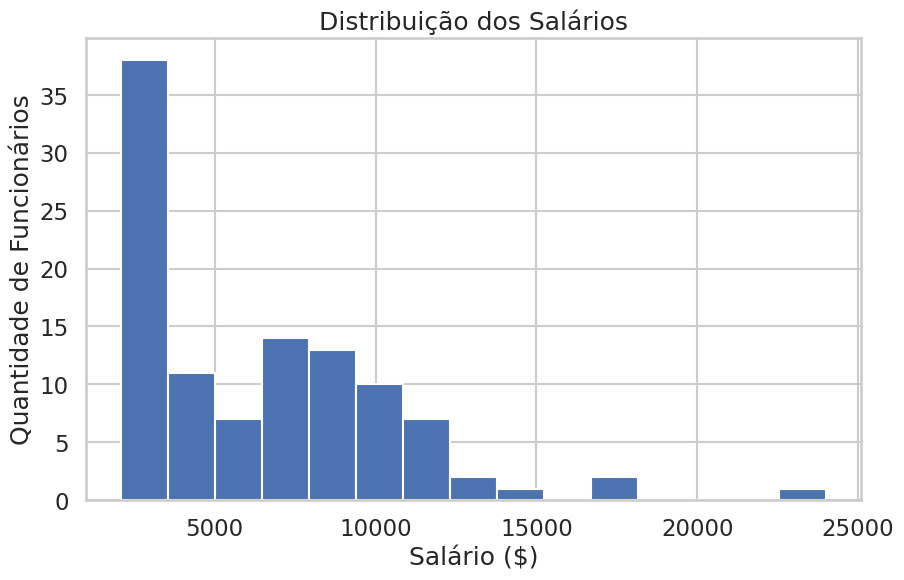

In [12]:
#GRÁFICO EM BARRA DA DISTRIBUIÇÃO SALARIAL - QUERY_01

plt.figure(figsize=(10, 6))

plt.hist(
    df_salarios['SALARY'],
    bins=15
)

plt.title('Distribuição dos Salários')
plt.xlabel('Salário ($)')
plt.ylabel('Quantidade de Funcionários')

plt.show()

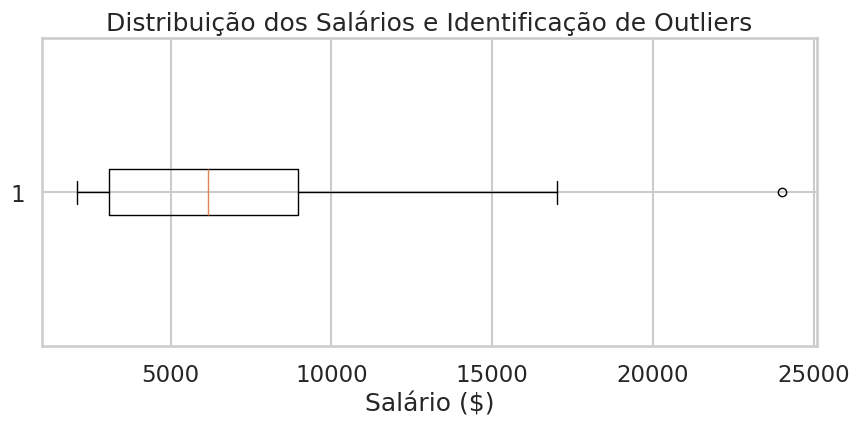

In [13]:
#BOXPLOT DOS SALÁRIOS - QUERY_01

plt.figure(figsize=(10, 4))

plt.boxplot(
    df_salarios['SALARY'],
    vert=False
)

plt.title('Distribuição dos Salários e Identificação de Outliers')
plt.xlabel('Salário ($)')

plt.show()

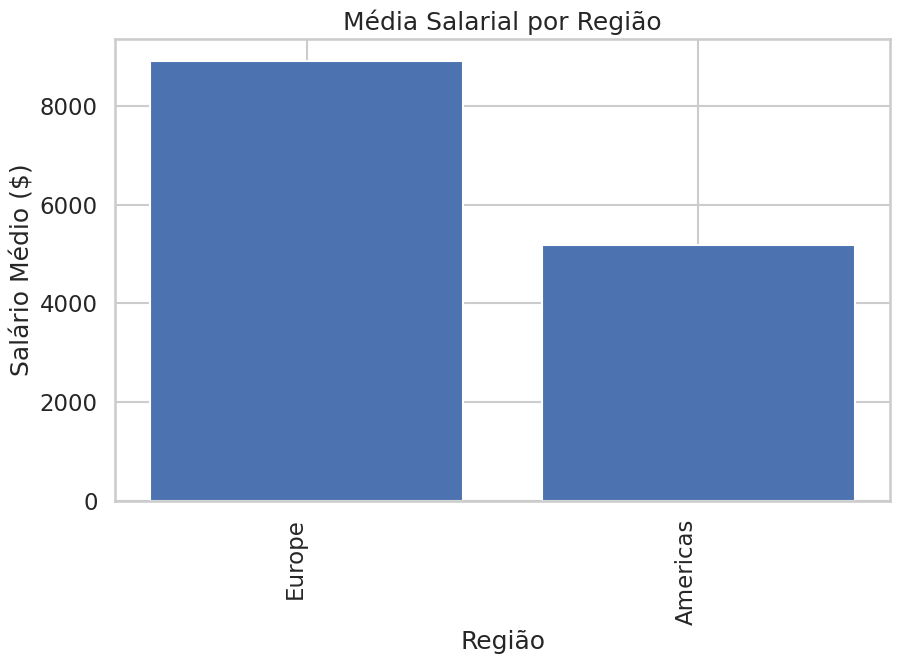

In [14]:
#MÉDIA SALARIAL POR REGIÃO - QUERY_01

media_por_regiao = (
    df_regioes
    .groupby('REGION_NAME')['SALARY']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    media_por_regiao.index,
    media_por_regiao.values
)

plt.title('Média Salarial por Região')
plt.xlabel('Região')
plt.ylabel('Salário Médio ($)')

plt.xticks(rotation=90, ha='right')

plt.show()

In [15]:
# ANALISANDO A QUERY_02

funcionarios_por_regiao = (
    df_regioes
    .groupby('REGION_NAME')['EMPLOYEE_ID']
    .count()
    .sort_values(ascending=False)
)

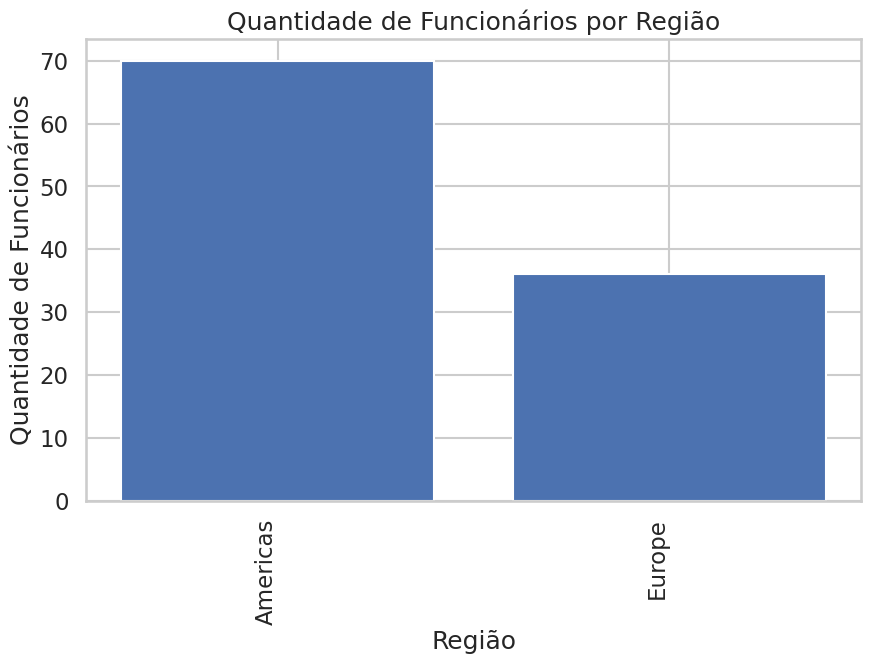

In [16]:
#GRÁFICO EM BARRA DA QUANTIDADE DE FUNCIONÁRIOS POR REGIÃO - QUERY_02

plt.figure(figsize=(10, 6))

plt.bar(
    funcionarios_por_regiao.index,
    funcionarios_por_regiao.values
)

plt.title('Quantidade de Funcionários por Região')
plt.xlabel('Região')
plt.ylabel('Quantidade de Funcionários')

plt.xticks(rotation=90, ha='right')

plt.show()

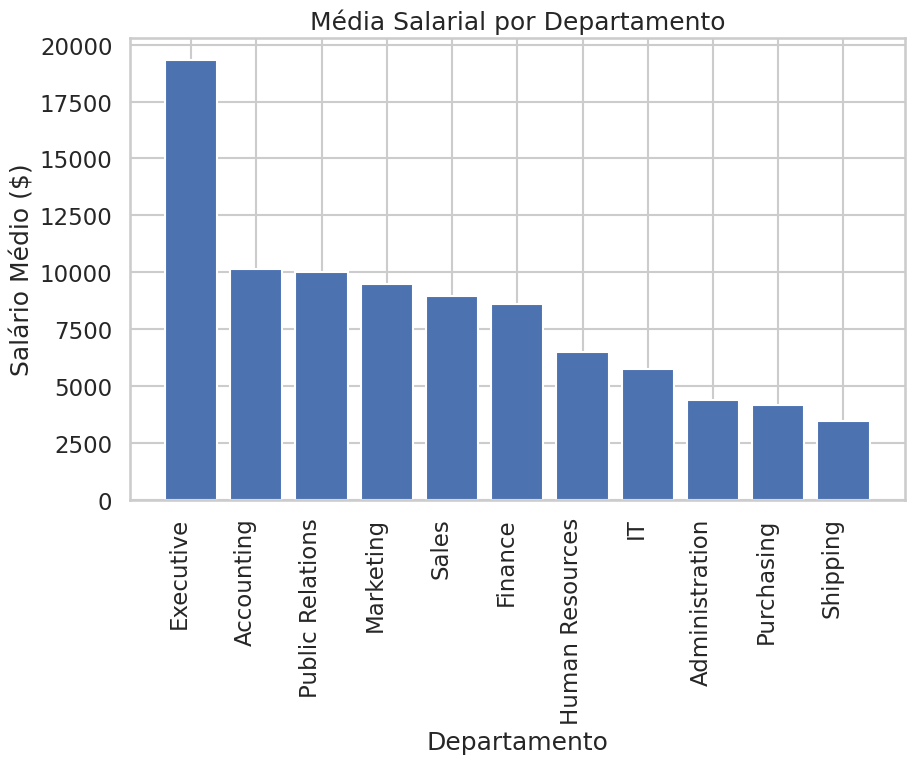

In [17]:
#MÉDIA SALARIAL POR DEPARTAMENTO - QUERY_01

media_por_departamento = (
    df_salarios
    .groupby('DEPARTMENT_NAME')['SALARY']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    media_por_departamento.index,
    media_por_departamento.values
)

plt.title('Média Salarial por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salário Médio ($)')

plt.xticks(rotation=90, ha='right')

plt.show()

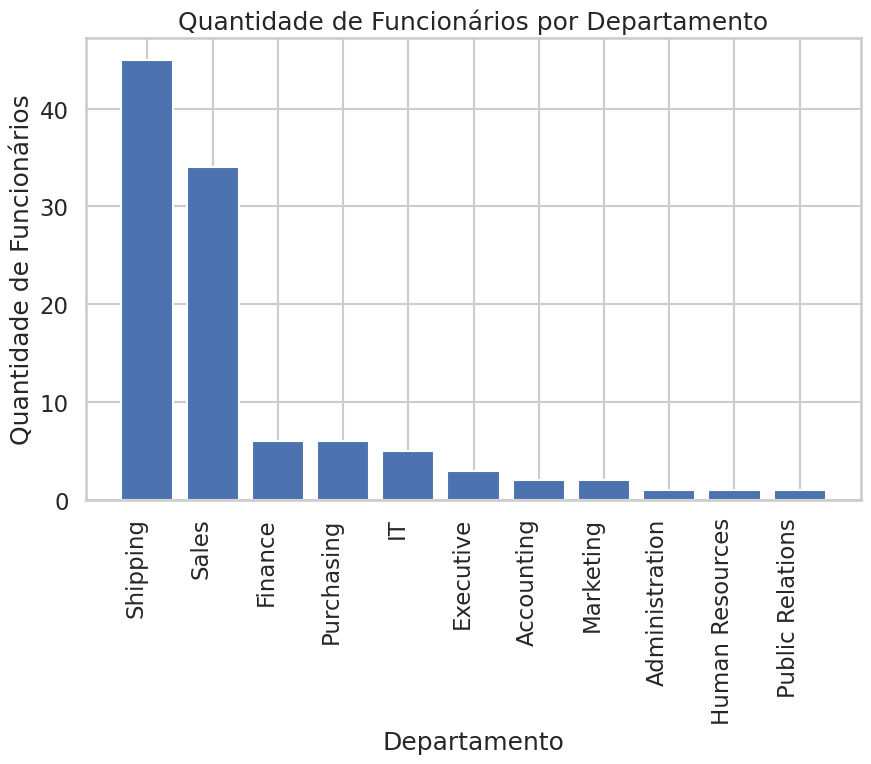

In [18]:
#QUANTIDADE DE FUNCIONÁRIOS POR DEPARTAMENTO

funcionarios_por_departamento = (
    df_salarios
    .groupby('DEPARTMENT_NAME')['EMPLOYEE_ID']
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    funcionarios_por_departamento.index,
    funcionarios_por_departamento.values
)

plt.title('Quantidade de Funcionários por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Quantidade de Funcionários')

plt.xticks(rotation=90, ha='right')

plt.show()

In [19]:
#MÉDIA SALARIAL DE CADA CARGO

media_por_cargo = (
    df_salarios
    .groupby('JOB_TITLE')['SALARY']
    .mean()
    .sort_values(ascending=False)
)


In [20]:
#MÉDIA SALARIAL E FAIXA SALARIAL POR CARGO

faixa_salarial_cargos = (
    df_salarios
    .groupby('JOB_TITLE')
    .agg(
        SALARY=('SALARY', 'mean'),
        JOB_MIN_SALARY=('JOB_MIN_SALARY', 'first'),
        JOB_MAX_SALARY=('JOB_MAX_SALARY', 'first')
    )
)

In [21]:
# 10 CARGOS COM MAIOR SALÁRIO MÉDIO

top_10_cargos_faixa = (
    faixa_salarial_cargos
    .sort_values('SALARY', ascending=False)
    .head(10)
)

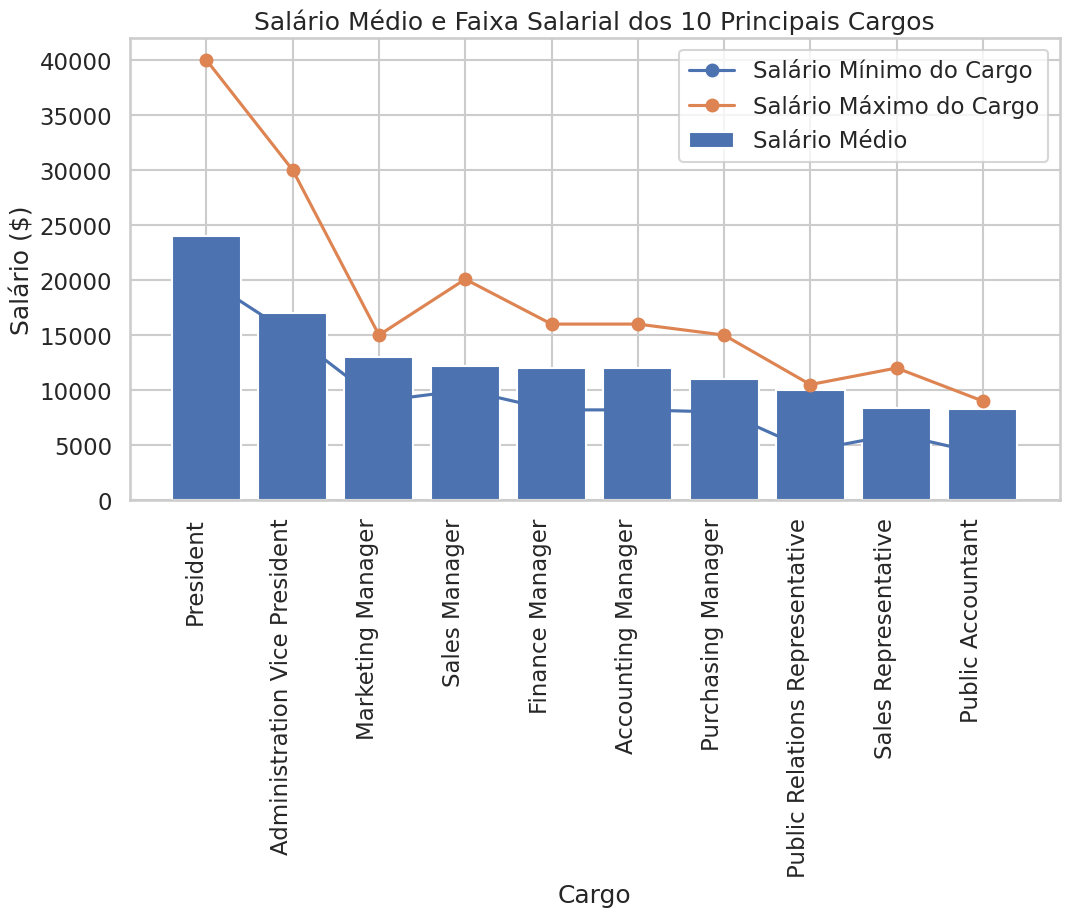

In [22]:
#GRÁFICO DA ANÁLISE

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['SALARY'],
    label='Salário Médio'
)

plt.plot(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['JOB_MIN_SALARY'],
    marker='o',
    label='Salário Mínimo do Cargo'
)

plt.plot(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['JOB_MAX_SALARY'],
    marker='o',
    label='Salário Máximo do Cargo'
)

plt.title('Salário Médio e Faixa Salarial dos 10 Principais Cargos')
plt.xlabel('Cargo')
plt.ylabel('Salário ($)')

plt.xticks(rotation=90, ha='right')
plt.legend()

plt.show()

In [23]:
media_por_departamento = (
    df_salarios
    .groupby('DEPARTMENT_NAME')['SALARY']
    .mean()
    .sort_values(ascending=False)
)

In [24]:
faixa_salarial_cargos = (
    df_salarios
    .groupby('JOB_TITLE')
    .agg(
        SALARY=('SALARY', 'mean'),
        JOB_MIN_SALARY=('JOB_MIN_SALARY', 'first'),
        JOB_MAX_SALARY=('JOB_MAX_SALARY', 'first')
    )
)

In [25]:
top_10_cargos_faixa = (
    faixa_salarial_cargos
    .sort_values('SALARY', ascending=False)
    .head(10)
)

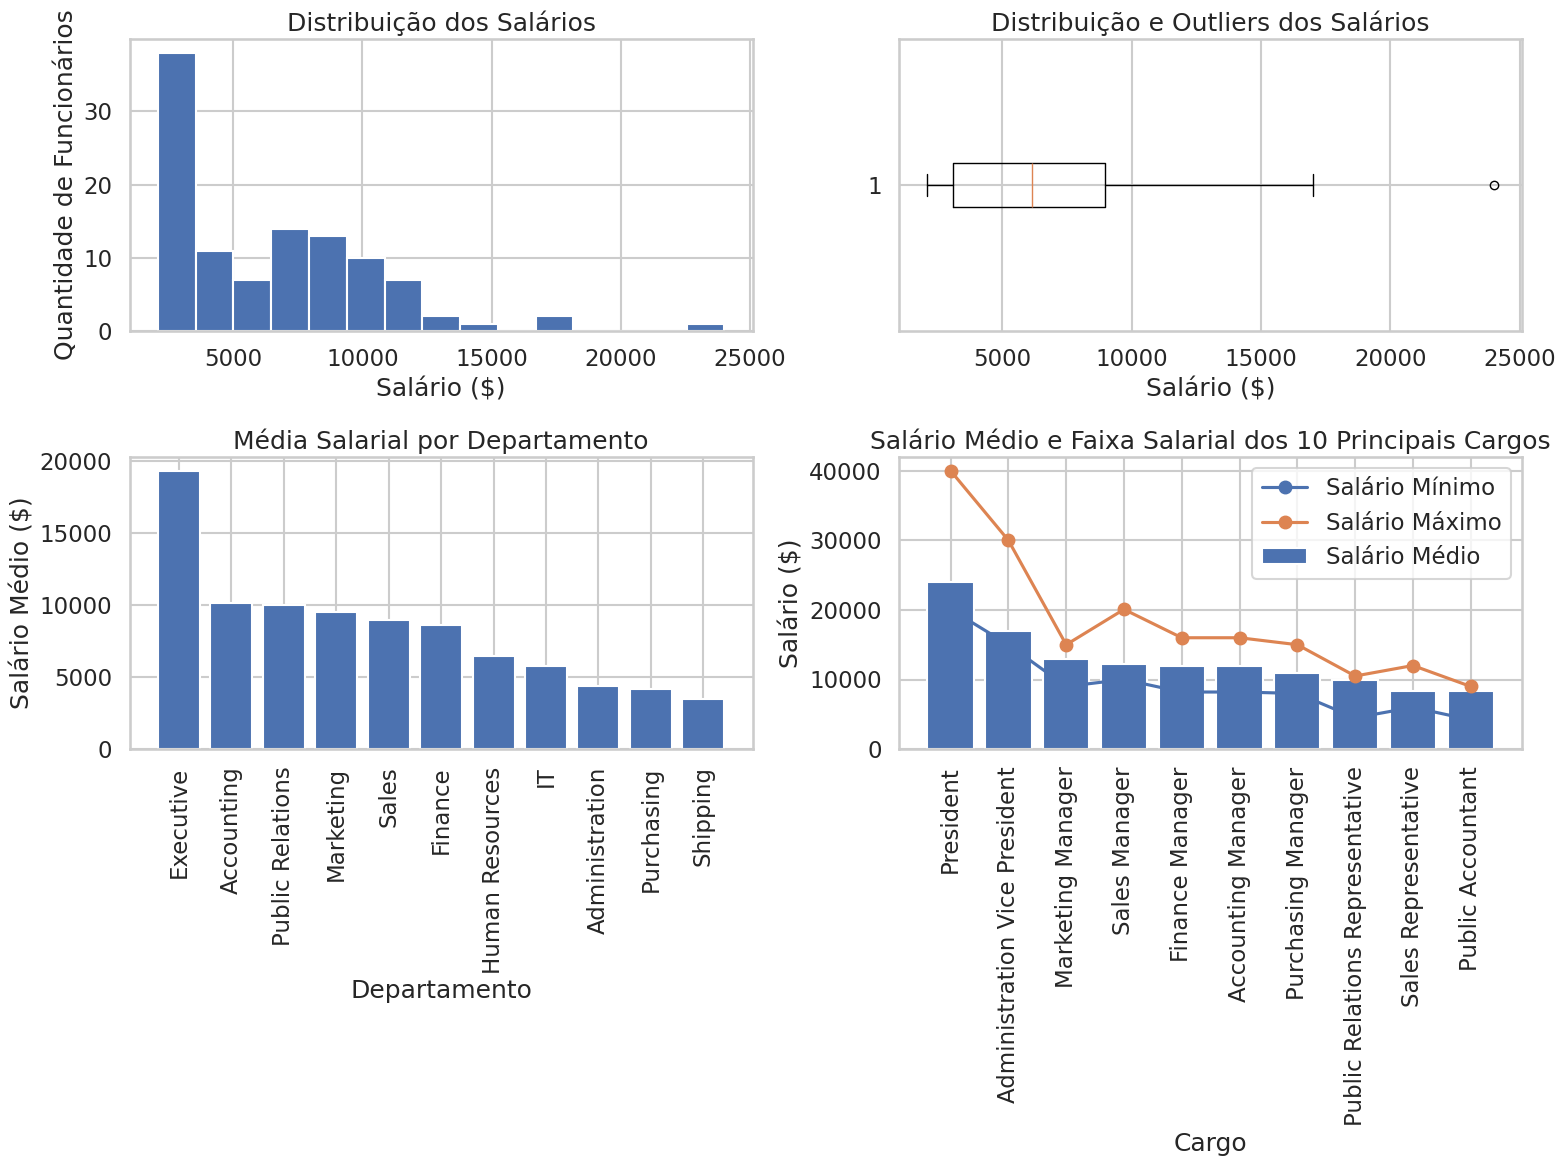

In [26]:
#PAINEL FINAL DE ANÁLISE SALARIAL - HISTOGRAMA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


#1. DISTRIBUIÇÃO DOS SALÁRIOS

axes[0, 0].hist(
    df_salarios['SALARY'],
    bins=15
)

axes[0, 0].set_title('Distribuição dos Salários')
axes[0, 0].set_xlabel('Salário ($)')
axes[0, 0].set_ylabel('Quantidade de Funcionários')


#2. BOXPLOT DOS SALÁRIOS

axes[0, 1].boxplot(
    df_salarios['SALARY'],
    vert=False
)

axes[0, 1].set_title('Distribuição e Outliers dos Salários')
axes[0, 1].set_xlabel('Salário ($)')


#3. MÉDIA SALARIAL POR DEPARTAMENTO

axes[1, 0].bar(
    media_por_departamento.index,
    media_por_departamento.values
)

axes[1, 0].set_title('Média Salarial por Departamento')
axes[1, 0].set_xlabel('Departamento')
axes[1, 0].set_ylabel('Salário Médio ($)')
axes[1, 0].tick_params(axis='x', rotation=90)


#4. SALÁRIO MÉDIO X FAIXA SALARIAL DOS CARGOS

axes[1, 1].bar(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['SALARY'],
    label='Salário Médio'
)

axes[1, 1].plot(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['JOB_MIN_SALARY'],
    marker='o',
    label='Salário Mínimo'
)

axes[1, 1].plot(
    top_10_cargos_faixa.index,
    top_10_cargos_faixa['JOB_MAX_SALARY'],
    marker='o',
    label='Salário Máximo'
)

axes[1, 1].set_title('Salário Médio e Faixa Salarial dos 10 Principais Cargos')
axes[1, 1].set_xlabel('Cargo')
axes[1, 1].set_ylabel('Salário ($)')
axes[1, 1].tick_params(axis='x', rotation=90)
axes[1, 1].legend()


plt.tight_layout()

#SALVAR A FIGURA

plt.tight_layout()

# SALVAR O PAINEL
fig.savefig(
    'painel_analise_salarial_final.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [27]:
#BAIXAR GRÁFICOS

from google.colab import files

plt.tight_layout()

plt.savefig(
    'painel_analise_salarial.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>